In [1]:
%pip install pyserial
%pip install numpy pandas matplotlib
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import numpy as np
import pandas as pd
import tkinter as tk
import serial
import time
import matplotlib.pyplot as plt
from IPython import display
from datetime import datetime
import os 
import sys
import re
import signal
import openpyxl
import glob

plt.style.use("dark_background")

Check connection with the port and set the serial function (rest of the code will only work once this is ran)

In [39]:
def serial_ports():
    """ Lists serial port names

        :raises EnvironmentError:
            On unsupported or unknown platforms
        :returns:
            A list of the serial ports available on the system
    """
    if sys.platform.startswith('win'):
        ports = ['COM%s' % (i + 1) for i in range(256)]
    elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
        # this excludes your current terminal "/dev/tty"
        ports = glob.glob('/dev/tty[A-Za-z]*')
    elif sys.platform.startswith('darwin'):
        ports = glob.glob('/dev/tty.*')
    else:
        raise EnvironmentError('Unsupported platform')

    result = []
    for port in ports:
        try:
            s = serial.Serial(port)
            s.close()
            result.append(port)
        except (OSError, serial.SerialException):
            pass
    return result

def findDevice(question="hello", answer="", flush=False, timeout=5):
    for port in serial_ports():
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:
            time.sleep(2)  # let the board finish resetting after port open
            ser.reset_input_buffer()

            if flush:
                ser.flush()
                time.sleep(0.5)

            ser.write(question.encode())
            time.sleep(0.5)

            msg = ser.readline().decode(errors="replace")
            print(f"{port}: {msg!r}")
            if answer and answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    return None

def send_read_command(port, string, required_string=None, baudrate=115200, timeout=10):
    """
    Opens the serial port, sends a “hello” and then your command, and collects replies.
    Stops reading when either:
      • no more data arrives (an empty readline, i.e. per-read timeout fired), or
      • we see `required_string` in the response, if given, or
      • the overall `timeout` has elapsed.
    Returns the list of lines read so far.
    """
    lines = []
    start = time.monotonic()
    with serial.Serial(port, baudrate=baudrate, timeout=timeout) as ser:
        # hand-shake / mode set
        ser.setRTS(False)
        ser.flush()
        time.sleep(0.7)
        ser.write(b"hello\n")
        time.sleep(0.5)
        ser.write(f"{string}\n".encode())
        last_recv = time.monotonic()

        while True:
            # Check idle timeout
            now = time.monotonic()
            if now - last_recv >= timeout:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
            
            try:
                line = ser.readline().decode('utf-8', errors='replace').strip()
                # print(line)
                
                last_recv = time.monotonic() # Reset idle timer since we got data
            except Exception as e:
                print(f"Error reading line: {e!s}")
                break

            # if nothing arrived within per-read timeout, readline() returns b'' → line == ''
            if not line:
                print(f"No (additional) responses within user-set timeout: {timeout}s")
                return lines
                
            lines.append(line)

            # if we were waiting for a specific marker, stop when we see it
            if required_string and required_string in line:
                break
    return lines



In [3]:
PORT = findDevice(question="hello\r\n", answer="C12666MA,v1.0", timeout=5)
if not PORT:
    raise RuntimeError("Device not found on any port")# Replace with the appropriate serial port for your device      

ser = serial.Serial(PORT, baudrate=115200, timeout=5)
time.sleep(2)  # Wait for the serial connection to initialize
ser.reset_input_buffer()

ser.write(b"hello\n")
message = ser.readline()
print(message.decode().strip())
time.sleep(1)
ser.close()

COM10: 'C12666MA,v1.0\r\n'
Found device at: COM10, answer: C12666MA,v1.0

C12666MA,v1.0


In [4]:
#functions to set and get gain, integration time, and averaging count. cuttently not used in the notebook, but can be used to set the parameters of the device.
def set_gain(gain, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_gain,{gain}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_integration(integration_time, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_integration,{integration_time}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_avg(average_count, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_avg,{average_count}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def get_avg(port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"get_avg\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def get_integration(port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"get_integration\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()

def set_led(led_state, port=PORT):
    with serial.Serial(port, baudrate=115200, timeout=5) as ser:
        time.sleep(2)  # reset delay
        ser.reset_input_buffer()

        command = f"set_led,{led_state}\n"
        ser.write(command.encode())
        time.sleep(0.1)
        response = ser.readline()
        return response.decode(errors="replace").strip()
    



In [ ]:
def measure_spec_raw(port=PORT, avg=15, integration_time=100000, gain=1, led = 0):
    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(2)
        ser.reset_input_buffer()

        if integration_time < 1280:
            integration_time = 1280

        if gain > 1:
            gain = 1

        if avg > 15:
            avg = 15 #avg over 15 will overload the arduino memory. Should also be capped at 15 in the arduino, but still.

        if led != 1:
            led = 0

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command(f"set_gain,{gain}")
        send_command(f"set_integration,{integration_time}")
        send_command(f"set_avg,{avg}")
        send_command(f"set_led,{led}")

        ser.write(b"spec,raw\n")
        spec_raw = ser.readline()
        spec_string = spec_raw.decode(errors="replace").strip()

        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        result = f"{timestamp}," + f"{avg}," + f"{integration_time}," + f"{gain}," + spec_string

        send_command(f"set_led,0")
        return result

In [ ]:
def measure_spec_raw(port=PORT, avg=15, integration_time=100000, gain=1, led = 0):
    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(2)
        ser.reset_input_buffer()

        if integration_time < 1280:
            integration_time = 1280

        if gain > 1:
            gain = 1

        if avg > 15:
            avg = 15 #avg over 15 will overload the arduino memory. Should also be capped at 15 in the arduino, but still.

        if led != 1:
            led = 0

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command(f"set_gain,{gain}")
        send_command(f"set_integration,{integration_time}")
        send_command(f"set_avg,{avg}")
        send_command(f"set_led,{led}")

        ser.write(b"spec,raw\n")
        spec_raw = ser.readline()
        spec_string = spec_raw.decode(errors="replace").strip()

        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        result = f"{timestamp}," + f"{avg}," + f"{integration_time}," + f"{gain}," + spec_string

        send_command(f"set_led,0")
        return result

# Set a dark spectrum, to be subtracted from a light spectrum later
dark_spectrum = None

def dark(port=PORT):
    global dark_spectrum

    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(2)
        ser.reset_input_buffer()

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command("set_gain,1")
        send_command("set_integration,100000")
        send_command("set_avg,10")
        send_command("set_led,0")

        ser.write(b"spec,raw\n")
        specdark = ser.readline()
        dark_spectrum = specdark.decode(errors="replace").strip()

    return dark_spectrum


dark()   # measure and store dark spectrum


def measure_spec(port=PORT, avg=15, integration_time=100000, gain=1, led=0):
    with serial.Serial(port, baudrate=115200, timeout=20) as ser:
        time.sleep(2)
        ser.reset_input_buffer()

        def send_command(cmd):
            ser.write((cmd + "\n").encode())
            return ser.readline().decode(errors="replace").strip()

        send_command(f"set_gain,{gain}")
        send_command(f"set_integration,{integration_time}")
        send_command(f"set_avg,{avg}")
        send_command(f"set_led,{led}")

        ser.write(b"spec,raw\n")
        spec_raw1 = ser.readline()
        spec_light1 = spec_raw1.decode(errors="replace").strip()

        send_command(f"set_led,0")

    spec_light = np.array(spec_light1.split(","), dtype=int)

    if dark_spectrum is None:
        raise ValueError("No dark spectrum has been measured. Call dark() first.")

    spec_dark = np.array(dark_spectrum.split(","), dtype=int)

    spec = np.maximum(spec_light - spec_dark, 0)

    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    spec_str = ",".join(spec.astype(str))

    result = f"{timestamp},{avg},{integration_time},{gain},{spec_str}"

    return result

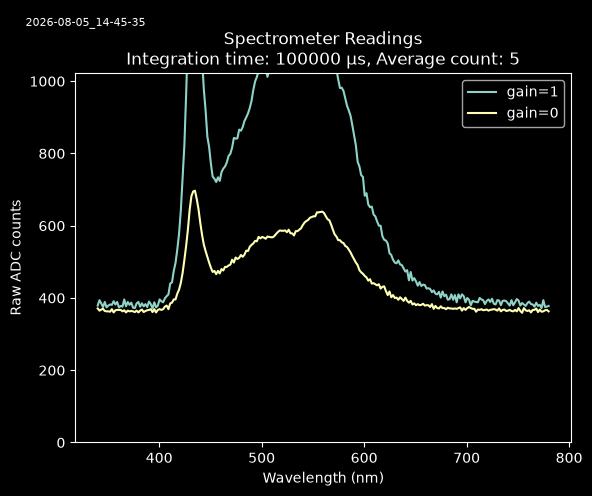

In [36]:
#Effect of gain on the spectrometer readings

read_high = measure_spec_raw(PORT, avg=5, integration_time=100000, gain=1)
read_low  = measure_spec_raw(PORT, avg=5, integration_time=100000, gain=0)

n_pixels = 256
columns = ["timestamp", "avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]

rows = [read_high.split(","), read_low.split(",")]
data = pd.DataFrame(rows, columns=columns)

# Numeric columns come in as strings from the split - convert them.
numeric_cols = ["avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]
data[numeric_cols] = data[numeric_cols].astype(int)

# Use the first measurement's timestamp for the filename.
first_timestamp = data.loc[0, "timestamp"]
safe_timestamp = first_timestamp.replace(":", "-").replace(" ", "_")
xlsx_filename = os.path.join("data", f"spec_{safe_timestamp}.xlsx")

data.to_excel(xlsx_filename, index=False)

# --- Plotting: use ONLY the pixel columns ---
pixel_cols = [c for c in data.columns if c.startswith("pixel")]
x = np.linspace(340, 780, len(pixel_cols))

for i in range(len(data)):
    y = data.loc[i, pixel_cols]
    label = f"gain={data.loc[i, 'gain']}"
    plt.plot(x, y, label=label)

plt.legend()
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.ylim(0, 1023)  # we have a 10-bit ADC counts
plt.xlabel("Wavelength (nm)")
plt.ylabel("Raw ADC counts")
plt.title("\n" + "Spectrometer Readings\n" + f"Integration time: {data.loc[0, 'integration_time']} µs, Average count: {data.loc[0, 'avg']}")
plt.show()

Measuring with config: [10, 50000, 1]
Measuring with config: [10, 100000, 1]
Measuring with config: [10, 200000, 1]


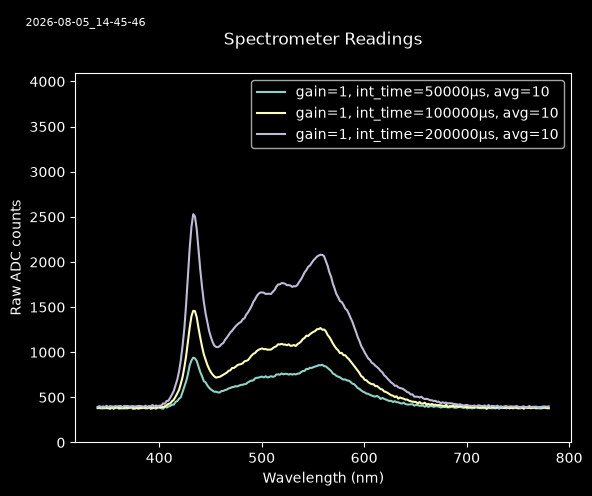

In [ ]:
#specify all configs for the plot [avg (max 63), integration time (µs, min 1280), gain (0 or 1, low or high), LED on/off (1 or 0)]
configs = [
    [10, 50000, 1, 0],
    [10, 100000, 1, 0],
    [10, 200000, 1, 0],
]

n_pixels = 256
columns = ["timestamp", "avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]

results = []

for config in configs:
    print(f"Measuring with config: {config}")
    read = measure_spec_raw(PORT, *config).split(",")
    results.append(read)

data = pd.DataFrame(results, columns=columns)

# Numeric columns come in as strings from the split - convert them.
numeric_cols = ["avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]
data[numeric_cols] = data[numeric_cols].astype(int)

first_timestamp = data.loc[0, "timestamp"]
safe_timestamp = first_timestamp.replace(":", "-").replace(" ", "_")
data.to_csv(os.path.join("data", f"spec {safe_timestamp}_data.csv"), index=False)

# --- Plotting: use ONLY the pixel columns ---
pixel_cols = [c for c in data.columns if c.startswith("pixel")]
x = np.linspace(340, 780, len(pixel_cols))

for i in range(len(data)):
    y = data.loc[i, pixel_cols]
    avg, int_time, gain = data.loc[i, 'avg'], data.loc[i, 'integration_time'], data.loc[i, 'gain']
    label = f"gain={gain}, int_time={int_time}µs, avg={avg}"
    plt.plot(x, y, label=label)

plt.legend()
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.ylim(0, 4095)  # we have a signed 13-bit ADC. Voltage will not be negative, so functionally 12 bits
plt.xlabel("Wavelength (nm)")
plt.ylabel("Raw ADC counts")
plt.title("\n" + "Spectrometer Readings\n")
plt.show()

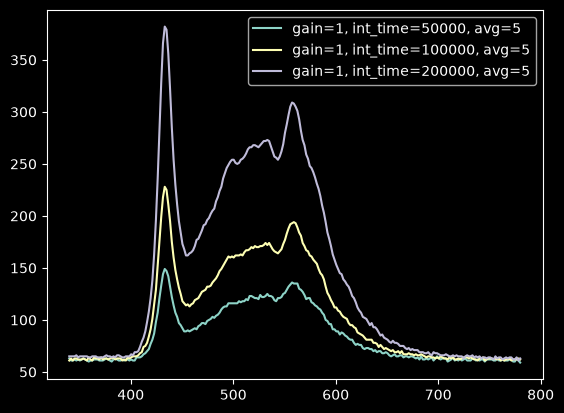

In [ ]:
for i in range(len(data)):
    y = data.loc[i, pixel_cols]
    avg, int_time, gain = data.loc[i, 'avg'], data.loc[i, 'integration_time'], data.loc[i, 'gain']
    plt.plot(x, y, label=f"gain={gain}, int_time={int_time}, avg={avg}")

plt.legend()
plt.show()

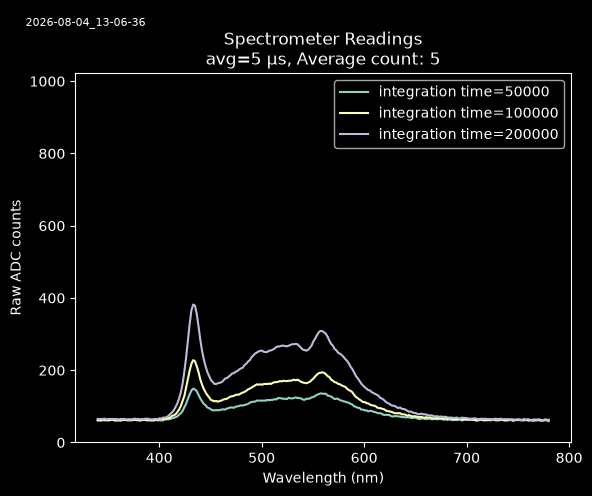

In [ ]:
# Old code ---- use other code

read1 = measure_spec_raw(PORT, avg=5, integration_time=50000, gain=1)
read2 = measure_spec_raw(PORT, avg=5, integration_time=100000, gain=1)
read3 = measure_spec_raw(PORT, avg=5, integration_time=200000, gain=1)


n_pixels = 256
columns = ["timestamp", "avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]

rows = [read1.split(","), read2.split(","), read3.split(",")]
data = pd.DataFrame(rows, columns=columns)

# Numeric columns come in as strings from the split - convert them.
numeric_cols = ["avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]
data[numeric_cols] = data[numeric_cols].astype(int)

# Use the first measurement's timestamp for the filename.
first_timestamp = data.loc[0, "timestamp"]
safe_timestamp = first_timestamp.replace(":", "-").replace(" ", "_")
xlsx_filename = os.path.join("data", f"spec_{safe_timestamp}.xlsx")

data.to_excel(xlsx_filename, index=False)

# --- Plotting: use ONLY the pixel columns ---
pixel_cols = [c for c in data.columns if c.startswith("pixel")]
x = np.linspace(340, 780, len(pixel_cols))

for i in range(len(data)):
    y = data.loc[i, pixel_cols]
    label = f"integration time={data.loc[i, 'integration_time']}"
    plt.plot(x, y, label=label)

plt.legend()
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.ylim(0, 1023)  # we have a 10-bit ADC counts
plt.xlabel("Wavelength (nm)")
plt.ylabel("Raw ADC counts")
plt.title("\n" + "Spectrometer Readings\n" + f"avg={data.loc[0, 'avg']} µs, Average count: {data.loc[0, 'avg']}")
plt.show()

In [52]:
dark()

'386,375,379,391,379,375,377,379,379,386,391,384,381,378,381,385,378,385,382,385,377,389,383,373,374,383,379,387,379,383,382,387,376,376,381,380,378,381,375,391,382,388,387,384,383,387,388,377,370,389,391,379,385,378,384,383,385,370,382,377,378,389,381,381,393,374,390,380,371,381,381,377,393,384,384,386,383,378,392,372,394,378,382,385,389,387,381,388,383,390,385,378,392,381,391,382,383,381,379,386,380,389,388,383,393,377,376,393,379,383,385,387,384,387,385,374,384,394,384,390,386,383,392,390,385,393,389,387,385,398,407,394,390,398,391,393,395,392,393,390,395,395,392,384,397,394,394,396,394,397,396,383,394,393,393,387,387,398,392,384,388,398,385,387,387,376,389,386,384,384,387,391,380,394,391,382,386,389,385,390,386,378,387,387,391,380,378,385,388,386,384,387,385,391,391,380,389,381,394,379,394,376,381,379,381,383,389,387,389,390,381,392,382,391,380,386,386,381,384,377,393,381,381,377,382,382,385,379,390,385,393,387,383,390,381,372,385,381,381,384,390,387,385,386,400,377,387,396,392,385

In [56]:
measure_spec()

'2026-08-05 16:20:37,15,100000,1,28,34,29,21,29,22,19,29,28,22,27,27,25,24,39,25,28,27,15,36,23,26,22,32,30,16,31,33,27,27,32,28,28,29,30,42,23,40,50,48,55,66,87,81,114,141,163,219,281,360,449,567,682,755,792,779,728,637,566,491,440,394,366,328,312,281,285,273,278,289,283,295,294,311,328,333,337,341,363,358,375,362,383,391,411,422,427,448,456,475,487,487,498,493,499,497,483,480,499,501,511,519,526,539,527,532,530,520,518,523,511,519,526,542,543,562,569,605,610,624,622,643,646,651,659,663,663,660,637,624,602,572,551,530,513,483,471,460,454,440,436,419,406,392,370,345,324,311,292,276,260,240,231,224,222,212,201,210,194,169,176,169,160,141,138,136,120,116,117,108,108,108,96,100,83,78,89,78,69,66,56,70,58,69,56,65,53,48,62,40,52,41,45,44,40,35,42,27,44,42,50,29,43,28,29,38,39,38,32,32,35,36,25,29,36,28,27,27,25,28,30,32,28,28,29,22,27,35,27,29,34,32,25,29,27,24,21,31,24,31,25,20,39,32,24,22,28,31,32,23,30,24,19,25,23,19'

In [41]:
measure_spec_raw()

'2026-08-05 14:51:24,1,100000,1,391,374,384,373,384,374,382,381,363,382,359,381,382,387,407,401,375,410,407,403,398,395,399,398,370,396,412,391,377,382,382,361,374,375,377,377,394,393,428,424,456,447,475,453,494,512,575,659,750,849,972,1120,1291,1401,1478,1463,1392,1251,1143,1036,958,891,858,802,768,747,729,701,729,714,740,760,754,778,780,829,829,846,864,857,867,852,874,860,896,919,952,929,968,965,1016,1039,1043,1002,1014,998,1025,999,1040,1016,1050,1031,1041,1077,1080,1103,1083,1090,1076,1076,1049,1039,1073,1085,1063,1091,1125,1119,1153,1152,1179,1170,1203,1219,1236,1210,1244,1217,1232,1192,1182,1128,1122,1044,1063,993,1021,958,972,928,953,896,937,870,859,840,794,780,741,751,689,698,678,668,638,643,634,614,600,574,606,582,552,569,531,529,525,488,527,496,480,496,478,457,472,468,472,434,457,476,428,433,419,462,405,457,398,442,402,407,413,424,392,437,387,418,396,401,388,432,388,432,383,427,369,388,399,403,405,409,393,389,410,390,404,368,408,368,410,372,408,367,402,369,409,382,398,375,393

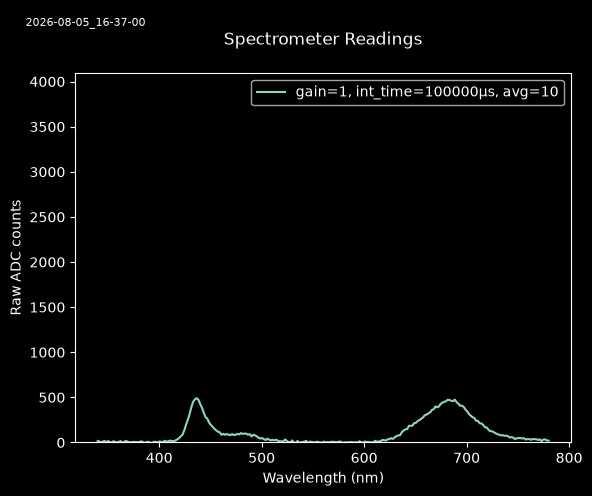

In [70]:
# Subtraction Spectra
# This code is similor to the one used above, but can be used to take two spectra and subtract the first from the second spectrum. 
# In the current case, 

#specify all configs for the plot [avg (max 63), integration time (µs, min 1280), gain (0 or 1, low or high), LED (0 or 1, On or off)]
configs = [
    [10, 100000, 1, 0],
    [10, 100000, 1, 1],
]

n_pixels = 256
columns = ["timestamp", "avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]

results = []

for config in configs:
    spectrum = measure_spec(
        avg=config[0],
        integration_time=config[1],
        gain=config[2],
        led=config[3]
    )
    results.append(spectrum.split(","))

data = pd.DataFrame(results, columns=columns)

# Numeric columns come in as strings from the split - convert them.
numeric_cols = ["avg", "integration_time", "gain"] + [f"pixel{i}" for i in range(n_pixels)]
data[numeric_cols] = data[numeric_cols].astype(int)

first_timestamp = data.loc[0, "timestamp"]
safe_timestamp = first_timestamp.replace(":", "-").replace(" ", "_")
data.to_csv(os.path.join("data", f"spec {safe_timestamp}_data.csv"), index=False)

# --- Plotting: use ONLY the pixel columns ---
pixel_cols = [c for c in data.columns if c.startswith("pixel")]
x = np.linspace(340, 780, len(pixel_cols))

Spec_subtraction = np.subtract(data.loc[1, pixel_cols], data.loc[0, pixel_cols])

y = Spec_subtraction
avg, int_time, gain = data.loc[1, 'avg'], data.loc[1, 'integration_time'], data.loc[1, 'gain']
label = f"gain={gain}, int_time={int_time}µs, avg={avg}"
plt.plot(x, y, label=label)

plt.legend()
plt.text(-0.1, 1.15, f"{safe_timestamp}", size=8, ha="left", va="top", transform=plt.gca().transAxes)
plt.ylim(0, 4096)  # we have a 10-bit ADC counts
plt.xlabel("Wavelength (nm)")
plt.ylabel("Raw ADC counts")
plt.title("\n" + "Spectrometer Readings\n")
plt.show()

So, the above meassurement sorta works. I will leave this for later, but what goes wrong is the following (i think...):
    The light goes on, and immediately, a capture is made by the spectrometer. Athough fluorescence is quite fast. i think the leaf does not have enough time to capture photons and convert these to fluorescence. since the fluorescence diminishes over a time, running this code twice in succession might not give fluorescence on the first capture, but might on the second.
        -- edit. Not a problem apparently.

In [13]:
ser.close()
